

Cognifyz Data Science Internship

Level 1 - Task 1: Data Exploration and Preprocessing

Objective:
To explore the dataset, identify missing values, analyze data types, and study the distribution of aggregate ratings.

In [1]:
from google.colab import files
uploaded = files.upload()


Saving Dataset .csv to Dataset .csv


In [3]:
import pandas as pd

df = pd.read_csv('Dataset .csv')

print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Rows and Columns:
(9551, 21)

Column Names:
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

First 5 Rows:
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century

In [4]:

print("Missing Values in Each Column:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nAggregate Rating Distribution:")
print(df['Aggregate rating'].value_counts())

Missing Values in Each Column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Data Types:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table boo

Observations:

• The dataset contains 9551 rows and 21 columns.

• Only the Cuisines column contains 9 missing values.

• The dataset includes both numerical and categorical features.

• Most restaurants have an aggregate rating of 0.0.

• The rating distribution is imbalanced.

Level 1 - Task 2: Descriptive Analysis

Objective:
To analyze statistical measures, identify top cities, and determine the most common cuisines.

In [6]:
print(df["City"].value_counts().head(10))

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


In [7]:
print(df["Cuisines"].value_counts().head(10))

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [8]:
print(df.describe())

       Restaurant ID  Country Code    Longitude     Latitude  \
count   9.551000e+03   9551.000000  9551.000000  9551.000000   
mean    9.051128e+06     18.365616    64.126574    25.854381   
std     8.791521e+06     56.750546    41.467058    11.007935   
min     5.300000e+01      1.000000  -157.948486   -41.330428   
25%     3.019625e+05      1.000000    77.081343    28.478713   
50%     6.004089e+06      1.000000    77.191964    28.570469   
75%     1.835229e+07      1.000000    77.282006    28.642758   
max     1.850065e+07    216.000000   174.832089    55.976980   

       Average Cost for two  Price range  Aggregate rating         Votes  
count           9551.000000  9551.000000       9551.000000   9551.000000  
mean            1199.210763     1.804837          2.666370    156.909748  
std            16121.183073     0.905609          1.516378    430.169145  
min                0.000000     1.000000          0.000000      0.000000  
25%              250.000000     1.000000        

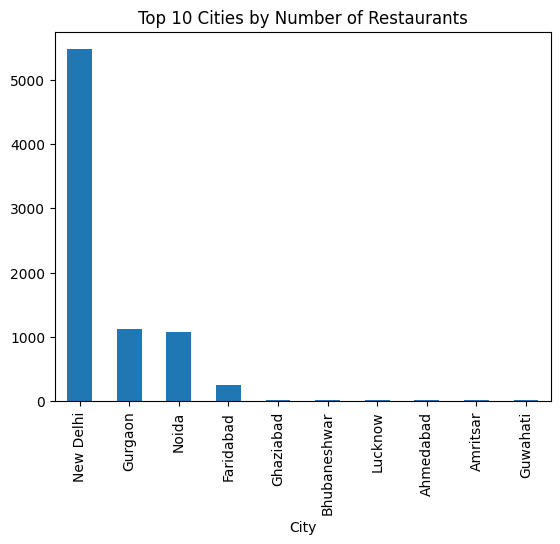

In [9]:
import matplotlib.pyplot as plt

df["City"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cities by Number of Restaurants")
plt.show()


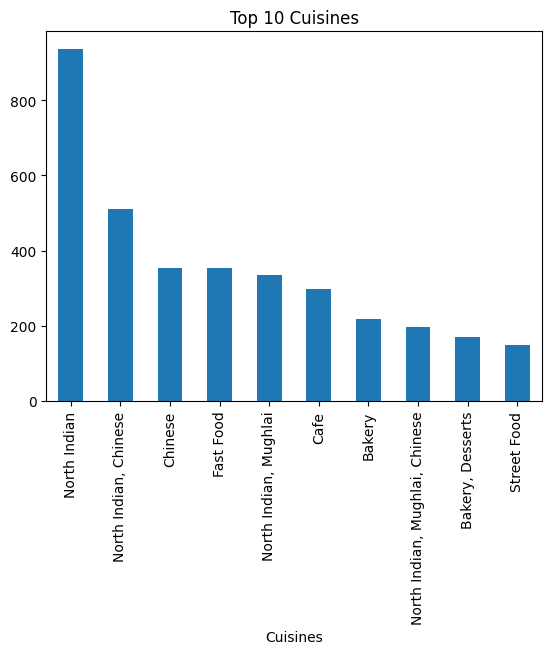

In [10]:
df["Cuisines"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cuisines")
plt.show()

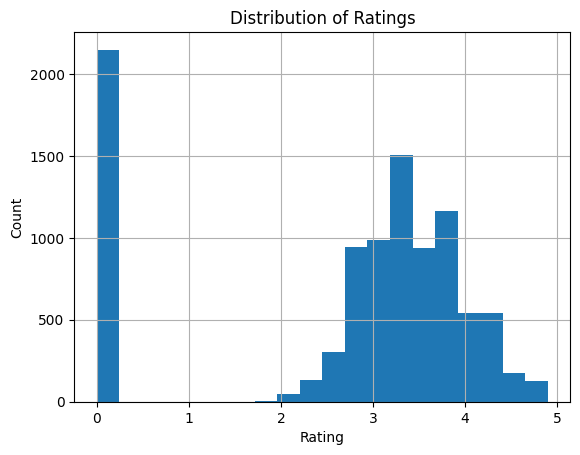

In [11]:
df["Aggregate rating"].hist(bins=20)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Observations:

• New Delhi has the highest number of restaurants (5473).

• Gurgaon and Noida are the second and third most represented cities.

• North Indian cuisine is the most popular cuisine with 936 restaurants.

• The average aggregate rating is 2.67.

• The median aggregate rating is 3.2.

• The dataset is highly concentrated in the Delhi NCR region.

Level 1 - Task 3: Geospatial Analysis

Objective:
To analyze restaurant locations using latitude and longitude and identify any relationship between location and ratings.

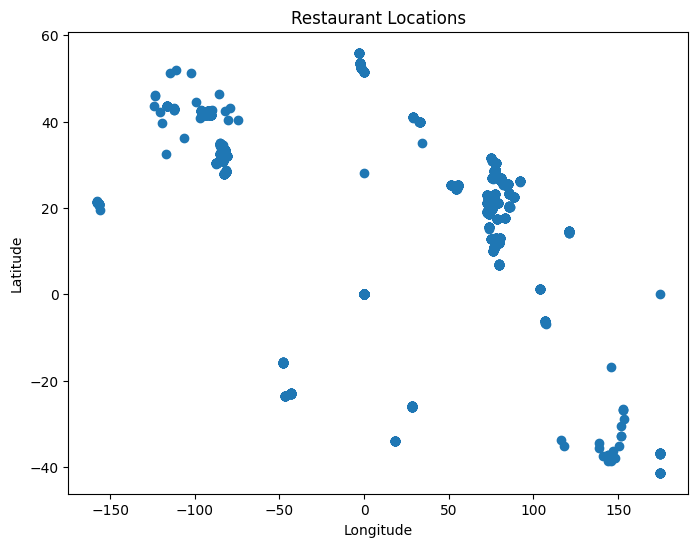

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(df["Longitude"], df["Latitude"])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Restaurant Locations")
plt.show()

In [13]:
city_rating = df.groupby("City")["Aggregate rating"].mean()

print(city_rating.sort_values(ascending=False).head(10))

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


Observations:

• Restaurant locations were visualized using latitude and longitude coordinates.

• Restaurants are distributed across multiple cities and countries.

• Some cities have higher average ratings than others.

• Inner City has the highest average restaurant rating (4.9).

• Quezon City and Makati City also show very high average ratings.

• Restaurant ratings may vary depending on location, indicating a possible relationship between geographic area and customer satisfaction.



---



Level 2 - Task 1: Price Range Analysis

Objective:
To analyze restaurant price ranges and study their relationship with aggregate ratings.

In [14]:
print("Most Common Price Range:")
print(df["Price range"].mode()[0])

print("\nAverage Rating by Price Range:")
print(df.groupby("Price range")["Aggregate rating"].mean())

Most Common Price Range:
1

Average Rating by Price Range:
Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


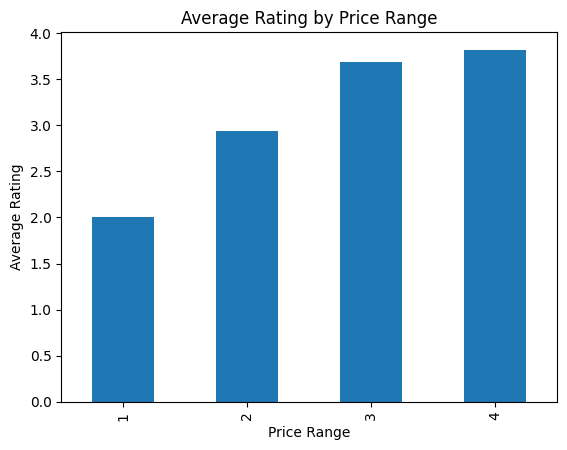

In [15]:
import matplotlib.pyplot as plt

df.groupby("Price range")["Aggregate rating"].mean().plot(kind="bar")
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.show()

Observations:

• The most common price range among restaurants is Price Range 1.

• Average ratings increase as the price range increases.

• Price Range 1 has an average rating of approximately 2.00.

• Price Range 4 has the highest average rating of approximately 3.82.

• Higher-priced restaurants tend to receive better ratings compared to lower-priced restaurants.

• There appears to be a positive relationship between price range and restaurant rating.

Level 2 - Task 2: Feature Engineering

Objective:
To create new features from existing columns and prepare data for analysis and machine learning.

In [16]:
df["Restaurant_Name_Length"] = df["Restaurant Name"].str.len()

df["Address_Length"] = df["Address"].str.len()

df["Has_Table_Booking"] = df["Has Table booking"].map({"Yes":1, "No":0})

df["Has_Online_Delivery"] = df["Has Online delivery"].map({"Yes":1, "No":0})

print(df[["Restaurant_Name_Length",
          "Address_Length",
          "Has_Table_Booking",
          "Has_Online_Delivery"]].head())

   Restaurant_Name_Length  Address_Length  Has_Table_Booking  \
0                      16              71                  1   
1                      16              67                  1   
2                      22              56                  1   
3                       4              70                  0   
4                      11              64                  1   

   Has_Online_Delivery  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  


Observations:

• New features were successfully created from existing columns.

• Restaurant_Name_Length represents the number of characters in the restaurant name.

• Address_Length represents the number of characters in the address.

• Has_Table_Booking and Has_Online_Delivery were converted into numerical values (1 = Yes, 0 = No).

• These engineered features can be used in machine learning models for better prediction.

• Feature engineering helps transform raw data into useful information for analysis.

Level 2 - Task 3: Predictive Modeling

Objective:
To build a machine learning model that predicts the aggregate rating of a restaurant using available features.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "Average Cost for two",
    "Price range",
    "Votes",
    "Has_Table_Booking",
    "Has_Online_Delivery"
]

X = df[features]
y = df["Aggregate rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 0.23633126773592328
R2 Score: 0.9411224550371614


Observations:

• A Random Forest Regressor model was used to predict restaurant aggregate ratings.

• The model was trained using Average Cost for Two, Price Range, Votes, Table Booking, and Online Delivery features.

• The Mean Absolute Error (MAE) is approximately 0.24, indicating low prediction error.

• The R² Score is 0.94, which means the model explains about 94% of the variation in restaurant ratings.

• The Random Forest model achieved strong predictive performance on the dataset.

• The selected features are useful in predicting restaurant ratings.